In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys
sys.path.append("..")
from ttnml.utils import plot_correlations

quimb not installed, partial_dm will not work


In [3]:
datadir = "../data/bbdata/asym_test.csv"
feature_names = [ "q_mu", "pt_mu", "r_mu", "q_k", "pt_k", "r_k", "q_pi", "pt_pi", "r_pi", "q_el", "pt_el", "r_el", "q_p", "pt_p", "r_p", "q_jet"]
df = pd.read_csv(datadir, header=None)
df.columns = ["label"] + feature_names
df.head()

,label,q_mu,pt_mu,r_mu,q_k,pt_k,r_k,q_pi,pt_pi,r_pi,q_el,pt_el,r_el,q_p,pt_p,r_p,q_jet
0,-1,0,0.000000,0.000000,-1,621.594692,0.274098,-1,640.158309,0.406300,-1,580.628513,0.157025,0,0.000000,0.000000,-0.058388
1,-1,-1,943.700097,0.235281,0,0.000000,0.000000,-1,352.859693,0.236086,-1,1155.352949,0.150904,0,0.000000,0.000000,-0.396256
2,1,0,0.000000,0.000000,0,0.000000,0.000000,1,1563.766333,0.244114,1,753.307507,0.132871,0,0.000000,0.000000,0.614398
3,1,-1,543.285288,0.279056,0,0.000000,0.000000,1,487.648273,0.334145,1,725.131482,0.146148,0,0.000000,0.000000,0.135605
4,1,0,0.000000,0.000000,-1,319.327450,0.286942,1,1124.074396,0.209833,-1,1219.722407,0.134649,1,324.902516,0.054107,-0.113222


In [4]:
for col in df.columns:
    if "pt" in col:
        df[col] = np.log1p(df[col])

In [16]:
np.array(feature_names)[[6, 4, 9, 7, 15, 12, 14, 13]]

array(['q_pi', 'pt_k', 'q_el', 'pt_pi', 'q_jet', 'q_p', 'r_p', 'pt_p'],
      dtype='<U5')

In [14]:
df.head()

,label,q_mu,pt_mu,r_mu,q_k,pt_k,r_k,q_pi,pt_pi,r_pi,q_el,pt_el,r_el,q_p,pt_p,r_p,q_jet
0,-1,0,0.000000,0.000000,-1,6.433896,0.274098,-1,6.463276,0.406300,-1,6.365832,0.157025,0,0.000000,0.000000,-0.058388
1,-1,-1,6.850868,0.235281,0,0.000000,0.000000,-1,5.868900,0.236086,-1,7.053026,0.150904,0,0.000000,0.000000,-0.396256
2,1,0,0.000000,0.000000,0,0.000000,0.000000,1,7.355492,0.244114,1,6.625800,0.132871,0,0.000000,0.000000,0.614398
3,1,-1,6.299474,0.279056,0,0.000000,0.000000,1,6.191643,0.334145,1,6.587731,0.146148,0,0.000000,0.000000,0.135605
4,1,0,0.000000,0.000000,-1,5.769344,0.286942,1,7.025604,0.209833,-1,7.107198,0.134649,1,5.786598,0.054107,-0.113222


In [5]:
signal = df[df["label"] == 1]
background = df[df["label"] == -1]

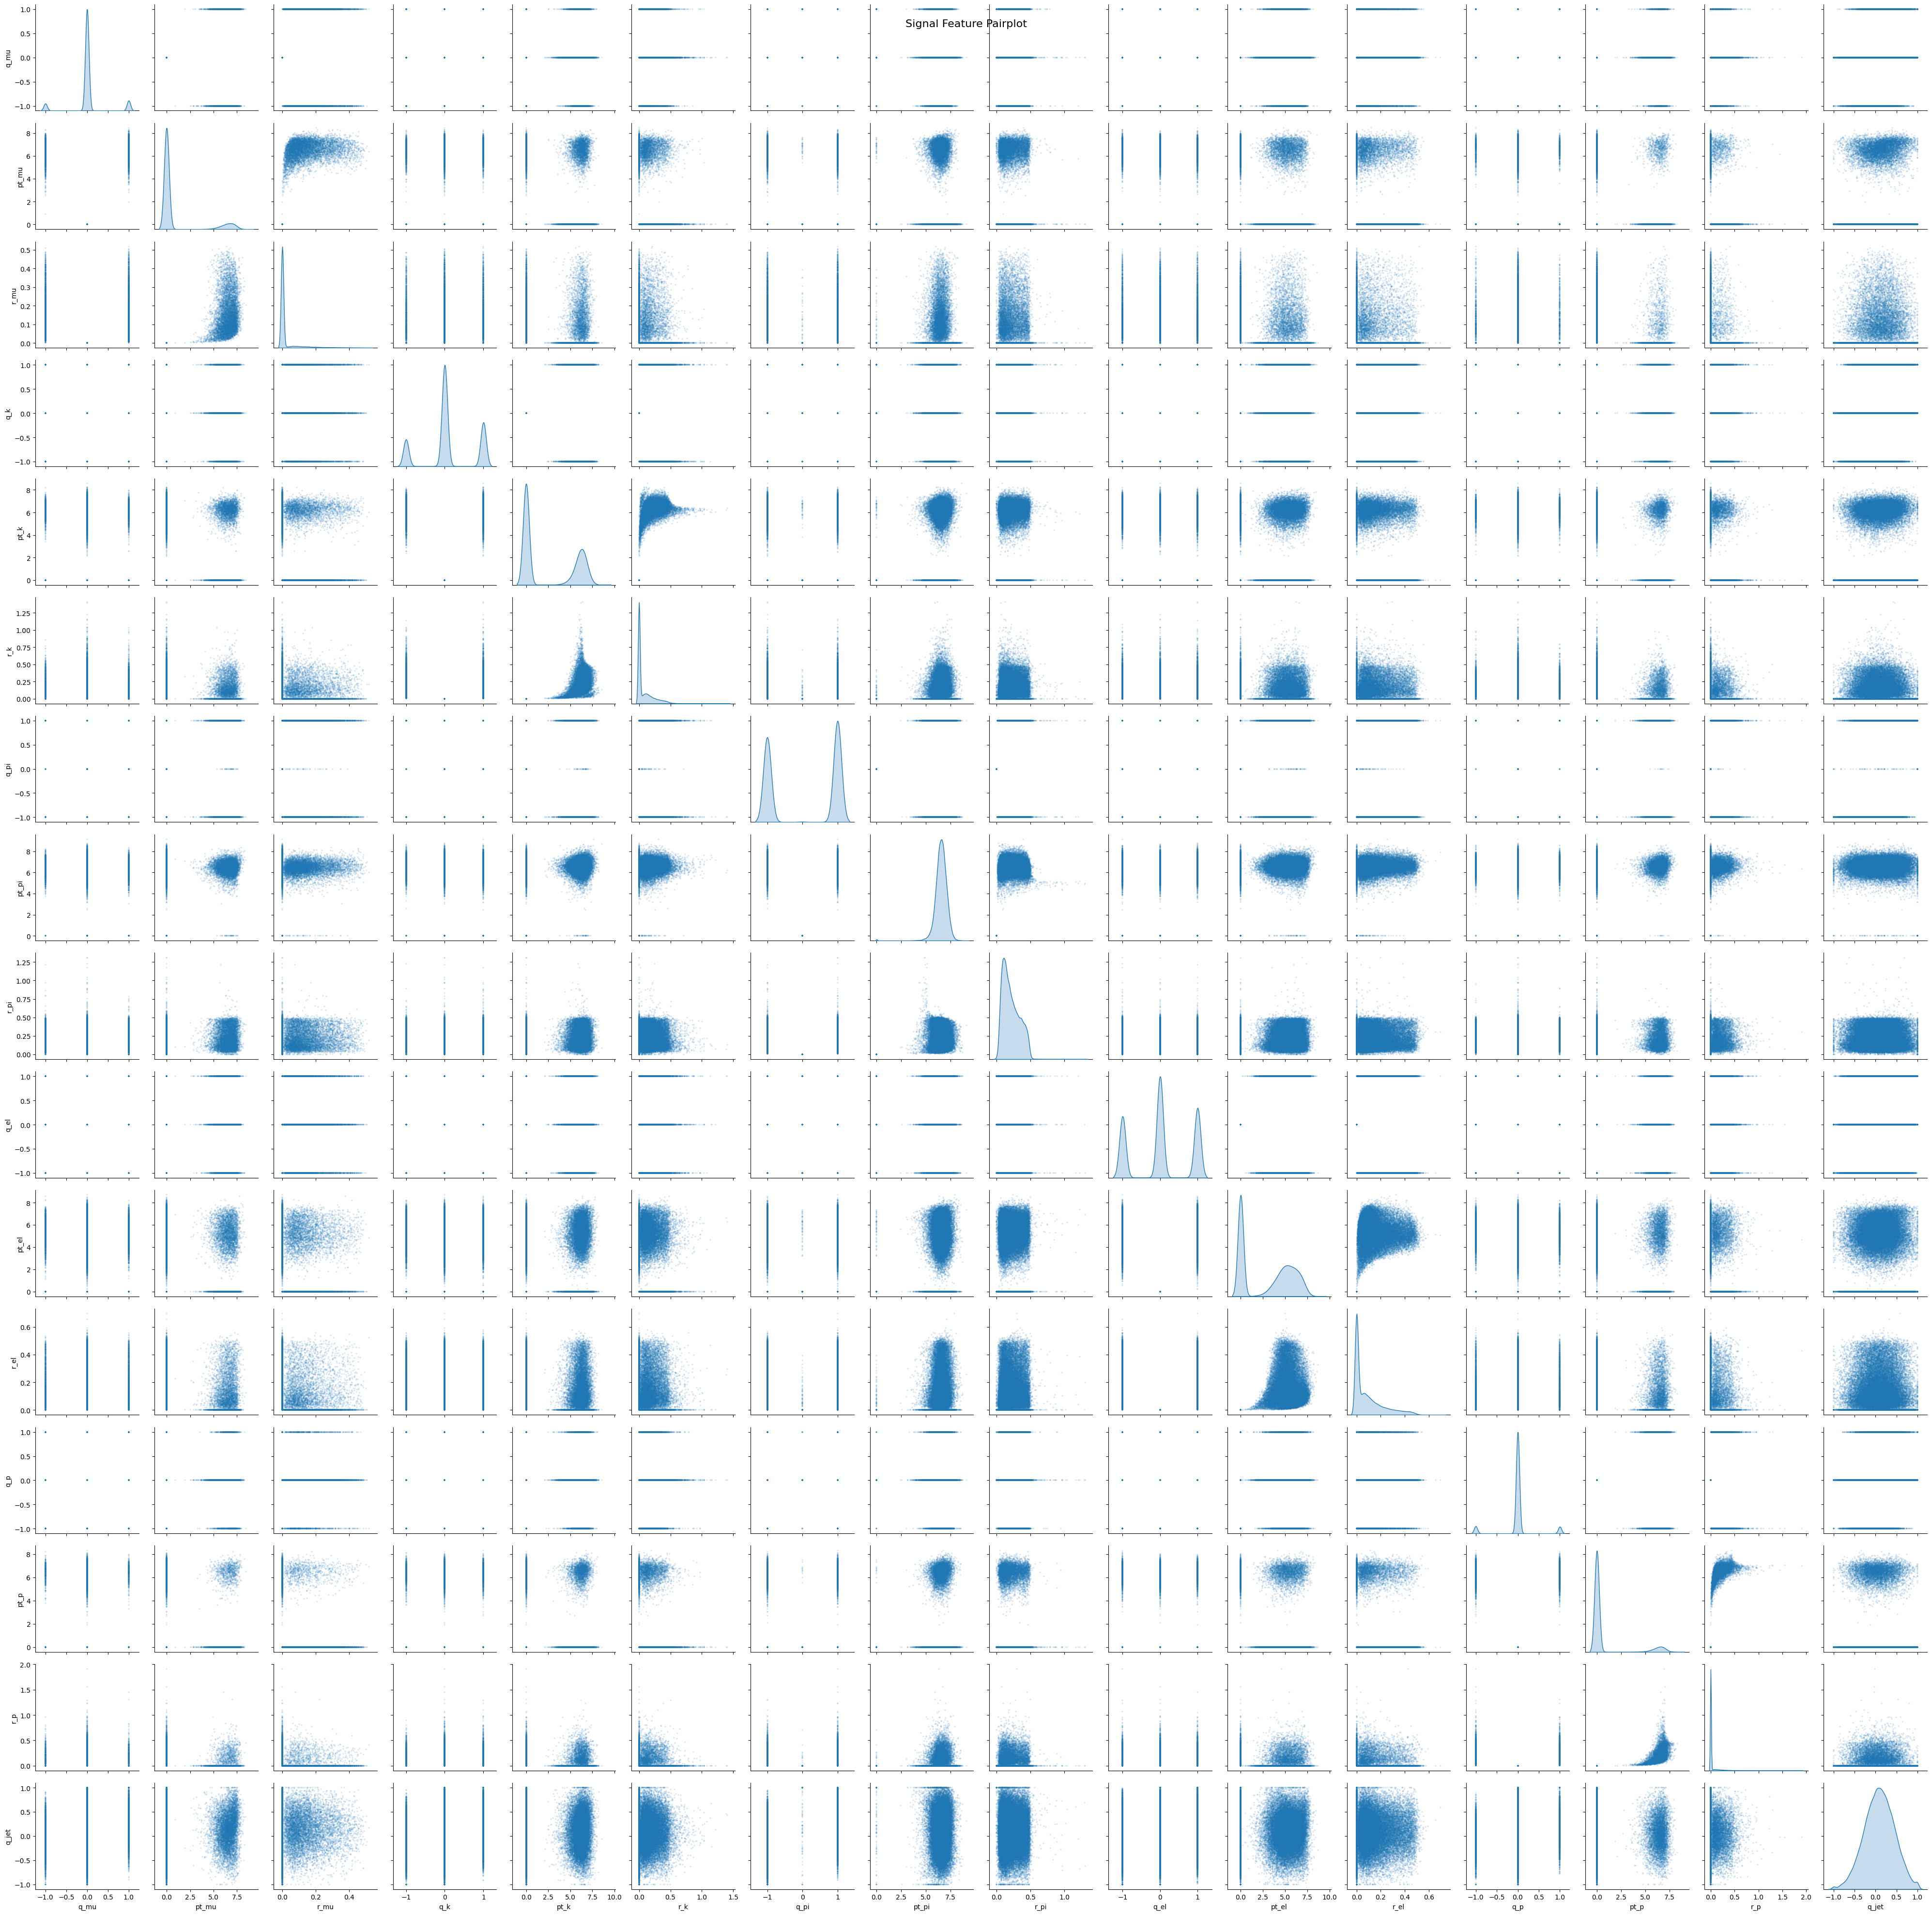

In [12]:
sns.pairplot(signal[feature_names], diag_kind="kde", markers="+", plot_kws={"alpha":0.5, "s":10})
plt.suptitle("Signal Feature Pairplot", fontsize=16)
plt.tight_layout()

In [13]:
plt.savefig("images/bbbar_signal_pairplot.pdf")

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'Feature Correlations for $b\\bar b$ jets\\ndataset')

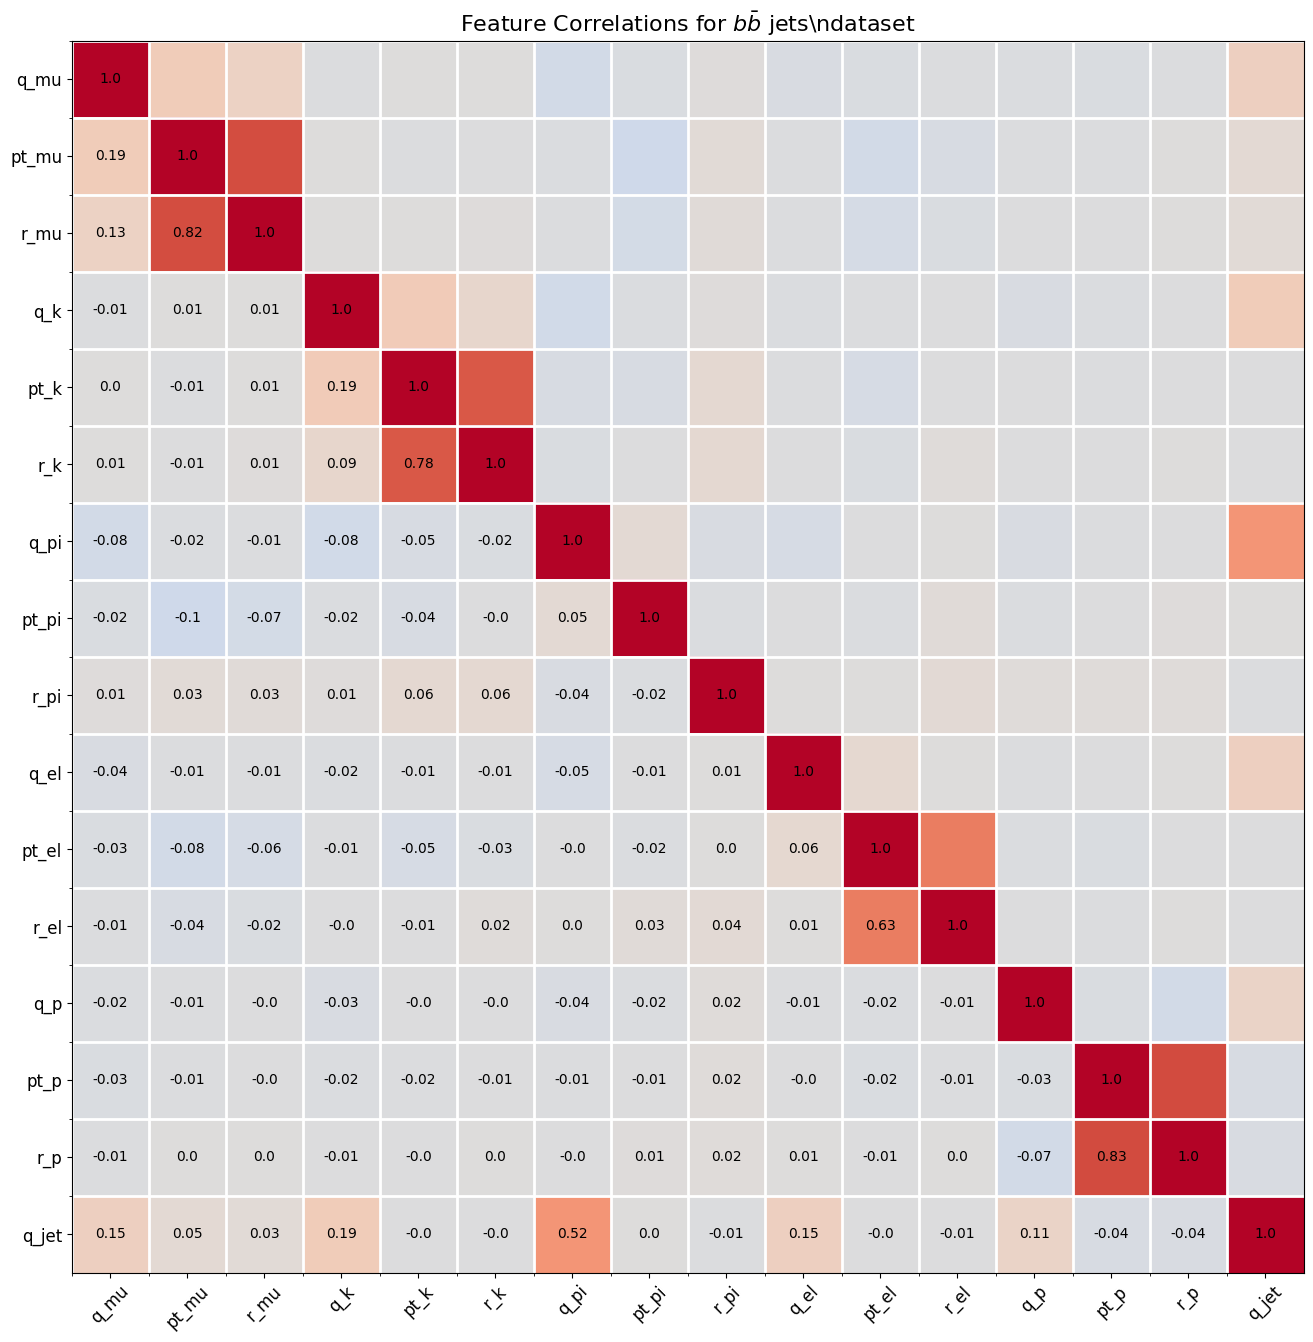

In [11]:
corr = signal[feature_names].corr().to_numpy()
corr = corr[:,:,np.newaxis]

fig, axs = plot_correlations(corr, features=feature_names, labels=[r"$b$"])
ax = axs[0]
ax.set_title(r"Feature Correlations for $b\bar b$ jets\ndataset", fontsize=16)